In [1]:
import os
import numpy as np
import sys
import sacc

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing


PyHMCode not installed!
PyHMCode not installed!
PyHMCode not installed!
euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

In [3]:
# SB needs noisless Cells
MGL = MGLensing.MGL("ini_files/config_files/config_spaceborne.yaml")

Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonli

In [4]:
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    # 'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.97,
    'h'         : 0.68,
    'Mnu'       : 0.0,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'a1_IA'   : 0., 
    'eta1_IA' : 0., 
    'beta_IA' : 0.,
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121, 
    'b1L_4': 0.60626, 
    'b1L_5': 0.779385,
    'b2L_1': -0.1322075,  
    'b2L_2': -0.0345375,  
    'b2L_3': 0.0579305,
    'b2L_4': 0.133662,
    'b2L_5': 0.232387,
    'bs2L_1': 0.1127485,  
    'bs2L_2': 0.0036835,  
    'bs2L_3': -0.1261985, 
    'bs2L_4': -0.285537,  
    'bs2L_5': -0.406101,  
    'blaplL_1': -0.100126,
    'blaplL_2': -0.1563475,
    'blaplL_3': -0.115281,
    'blaplL_4': 0.1059295,
    'blaplL_5': 0.361450, 
    'log10Mc_bc': 13.8,
    'eta_bc': -0.3,
    'beta_bc': -0.22 ,
    'log10Mz0_bc': 10.5,
    'thetaout_bc': 0.25,
    'thetainn_bc': -0.86,
    'log10Minn_bc': 12.4,
}     
model = {
    'nl_model' : 1,
    'bias_model' : 2,
    'baryon_model' : 3,
    'ia_model' : 0,
    'photoz_err_model' : 0,
    # Match these to config_spaceborne.yaml if you want TheoryModel covariance
    # (True/True). Previous exports used the defaults False/False.
    'heft_extrap_k_const': False,
    'cross_sqrt_baryon': False,
}

In [6]:
fsky = 0.43

# ells
ell_l = MGL.Survey.l_wl
ell_g = MGL.Survey.l_gc
ell_x = MGL.Survey.l_xc
lmin = 20
lbin = 20 
lmax = 5e3

ell_edges = MGL.Survey.ell_bin_edges  # np.logspace(log10(lmin), log10(lmax), num=self.lbin+1, endpoint=True) 
delta_ell = MGL.Survey.d_ell_bin   # np.diff(self.ell_bin_edges)
ell_centre = MGL.Survey.l_wl_bin_centers  # np.sqrt(self.ell_bin_edges[:-1] *self.ell_bin_edges[1:])
# printing this to double-check that they're the same as SB output (they are!)
print(ell_centre)

[  22.96034957   30.26045796   39.88159297   52.56171138   69.27339903
   91.29846968  120.32628227  158.58331751  209.00395258  275.45553264
  363.03500257  478.45985096  630.58335245  831.07362841 1095.30861093
 1443.55555531 1902.52557178 2507.42241125 3304.64265063 4355.33438618]


In [7]:
# Compute C_ell's at every integer ell from lmin to lmax (inclusive),
# then write noiseless spectra for Spaceborne.
n_ell_binned = MGL.Survey.lbin
ell_centers = np.array(MGL.Survey.l_wl_bin_centers)
ell_int = np.arange(int(MGL.Survey.lmin), int(MGL.Survey.lmax) + 1)

MGL.Survey.lbin = len(ell_int)
MGL.Survey.ell = MGL.Survey.l_wl = MGL.Survey.l_xc = MGL.Survey.l_gc = ell_int
MGL.Survey.nell_wl = MGL.Survey.nell_xc = MGL.Survey.nell_gc = len(ell_int)

cl_ll, cl_gg, _, cl_gl = MGL.get_c_ells(params, model)

MGL.Survey.lbin = n_ell_binned
MGL.Survey.ell = MGL.Survey.l_wl = MGL.Survey.l_xc = MGL.Survey.l_gc = ell_centers
MGL.Survey.nell_wl = MGL.Survey.nell_xc = MGL.Survey.nell_gc = n_ell_binned

for i in range(MGL.Survey.nbin_s):
    cl_ll[:, i, i] -= MGL.Survey.noise['LL']
for i in range(MGL.Survey.nbin_l):
    cl_gg[:, i, i] -= MGL.Survey.noise['GG']

print(cl_ll.shape, 'integer ells:', ell_int[0], '...', ell_int[-1])
ell_l = ell_int

# save as columns: ell, zi, zj, Cl[ell, zi, zj]
n_ell, n_z1, n_z2 = cl_ll.shape

ell_col = np.repeat(ell_l, n_z1 * n_z2)
zi_col = np.tile(np.repeat(np.arange(n_z1), n_z2), n_ell)
zj_col = np.tile(np.arange(n_z2), n_ell * n_z1)
cl_ll_col = cl_ll.reshape(-1)
cl_gg_col = cl_gg.reshape(-1)
cl_gl_col = cl_gl.reshape(-1)

with open('Spaceborne/data/cl_heft_logMc_ll_v2.txt', 'w') as f:
    np.savetxt(f, np.column_stack((ell_col, zi_col, zj_col, cl_ll_col)))

with open('Spaceborne/data/cl_heft_logMc_gg_v2.txt', 'w') as f:
    np.savetxt(f, np.column_stack((ell_col, zi_col, zj_col, cl_gg_col)))

with open('Spaceborne/data/cl_heft_logMc_gl_v2.txt', 'w') as f:
    np.savetxt(f, np.column_stack((ell_col, zi_col, zj_col, cl_gl_col)))



# z and n(z)
zz_integr = MGL.Survey.zz_integr  
dndz_sources = MGL.Survey.eta_z_s
dndz_lenses = MGL.Survey.eta_z_l
print(f'zmin {min(zz_integr)}, zmax {max(zz_integr)}')

# LSST Y1 number of galaxies (MGL.gal_per_sqarcmn_s or l)
# we consider the same number of galaxies per bin => divide the following numbers by 5
ngal_source = 10.0  
ngal_lens = 18.0  
print(f'Use {ngal_source/5} for sources, and {ngal_lens/5} for lenses')

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

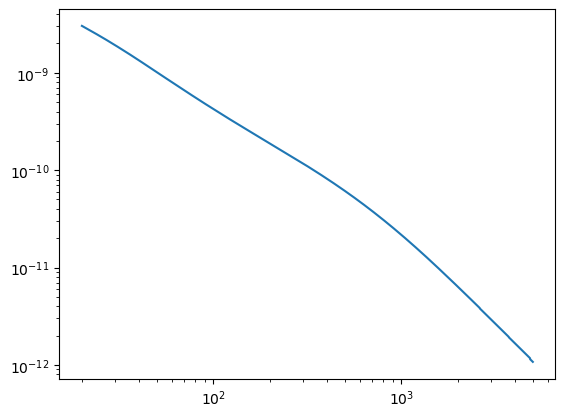

In [8]:
# test noise: plot Cells 
import matplotlib.pyplot as plt
i = 0
j = 0

plt.figure()
plt.loglog(ell_l, cl_ll[:,i,j])
plt.show()

In [11]:
path_nz_srd = 'MGLensing/n_of_z/forecast_fid.sacc'
s = sacc.Sacc.load_fits(path_nz_srd)


for n, t in s.tracers.items():
    print(t.name, t.quantity, type(t))

lens0 galaxy_density <class 'sacc.tracers.NZTracer'>
lens1 galaxy_density <class 'sacc.tracers.NZTracer'>
lens2 galaxy_density <class 'sacc.tracers.NZTracer'>
lens3 galaxy_density <class 'sacc.tracers.NZTracer'>
lens4 galaxy_density <class 'sacc.tracers.NZTracer'>
src0 galaxy_shear <class 'sacc.tracers.NZTracer'>
src1 galaxy_shear <class 'sacc.tracers.NZTracer'>
src2 galaxy_shear <class 'sacc.tracers.NZTracer'>
src3 galaxy_shear <class 'sacc.tracers.NZTracer'>
src4 galaxy_shear <class 'sacc.tracers.NZTracer'>


In [7]:
# print(s.tracers['lens0'].nz)
# print(s.tracers['lens1'].nz)
# print(s.tracers['lens2'].nz)
# print(s.tracers['lens3'].nz)
# print(s.tracers['lens4'].nz)
# print()
# for i in range(5):
#     print(dndz_lenses[i])

In [8]:
print(dndz_sources.shape)
print(zz_integr.shape)

# crate txt file with n(z) for len and source
with open('Spaceborne/data/nz_lens.txt', 'w') as f:
    np.savetxt(f, np.column_stack((zz_integr, dndz_lenses)))
f.close

with open('Spaceborne/data/nz_source.txt', 'w') as f:
    np.savetxt(f, np.column_stack((zz_integr, dndz_sources)))
f.close

(400, 5)
(400,)


<function TextIOWrapper.close()>

In [9]:
b_lin = [1.187684, 1.312375, 1.45121, 1.60626, 1.779385]
z_bin_center_l = np.array([3.083232685515536753e-01, 5.011373846158426737e-01, 6.981257392184466726e-01, 8.964730913147888058e-01, 1.095412294727920344e+00])  #from DESC github
bins_list = [0, 1, 2, 3, 4]

with open('Spaceborne/data/b_lin.txt', 'w') as f:
    np.savetxt(f, np.column_stack((z_bin_center_l, b_lin, b_lin, b_lin, b_lin, b_lin)))
f.close

<function TextIOWrapper.close()>